In [8]:
import pandas as pd
import numpy as np
from wordcloud import WordCloud
from collections import Counter
import re
from sklearn.feature_extraction.text import CountVectorizer
from nltk.util import ngrams
from nltk.corpus import stopwords
import nltk
import string
from nltk.tokenize import word_tokenize

In [10]:
df = pd.read_csv("/content/amazonreviews (2).tsv", sep="\t", names=['label' , 'review'], quoting = 3)
df

,label,review
0,label,review
1,pos,Stuning even for the non-gamer: This sound tra...
2,pos,The best soundtrack ever to anything.: I'm rea...
3,pos,"""Amazing!: This soundtrack is my favorite musi..."
4,pos,Excellent Soundtrack: I truly like this soundt...
...,...,...
9996,pos,"""A revelation of life in small town America in..."
9997,pos,Great biography of a very interesting journali...
9998,neg,Interesting Subject; Poor Presentation: You'd ...
9999,neg,Don't buy: The box looked used and it is obvio...


In [11]:
df = df.drop(df.index[0])
df

,label,review
1,pos,Stuning even for the non-gamer: This sound tra...
2,pos,The best soundtrack ever to anything.: I'm rea...
3,pos,"""Amazing!: This soundtrack is my favorite musi..."
4,pos,Excellent Soundtrack: I truly like this soundt...
5,pos,"Remember, Pull Your Jaw Off The Floor After He..."
...,...,...
9996,pos,"""A revelation of life in small town America in..."
9997,pos,Great biography of a very interesting journali...
9998,neg,Interesting Subject; Poor Presentation: You'd ...
9999,neg,Don't buy: The box looked used and it is obvio...


In [12]:
#Data Cleaning: Remove duplicates, handle missing reviews if any, preprocess text (lowercasing, stopwords removal).
df = df.drop_duplicates(subset='review')
df

,label,review
1,pos,Stuning even for the non-gamer: This sound tra...
2,pos,The best soundtrack ever to anything.: I'm rea...
3,pos,"""Amazing!: This soundtrack is my favorite musi..."
4,pos,Excellent Soundtrack: I truly like this soundt...
5,pos,"Remember, Pull Your Jaw Off The Floor After He..."
...,...,...
9996,pos,"""A revelation of life in small town America in..."
9997,pos,Great biography of a very interesting journali...
9998,neg,Interesting Subject; Poor Presentation: You'd ...
9999,neg,Don't buy: The box looked used and it is obvio...


In [13]:
df = df.dropna(subset = ['review'])
df = df[df['review'].str.strip() != ""]
df

,label,review
1,pos,Stuning even for the non-gamer: This sound tra...
2,pos,The best soundtrack ever to anything.: I'm rea...
3,pos,"""Amazing!: This soundtrack is my favorite musi..."
4,pos,Excellent Soundtrack: I truly like this soundt...
5,pos,"Remember, Pull Your Jaw Off The Floor After He..."
...,...,...
9996,pos,"""A revelation of life in small town America in..."
9997,pos,Great biography of a very interesting journali...
9998,neg,Interesting Subject; Poor Presentation: You'd ...
9999,neg,Don't buy: The box looked used and it is obvio...


In [14]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [15]:
#Text Preprocessing
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text) # remove punctuation and numbers
    text = re.sub(r"http\S+|www\S+|https\S+", '', text, flags=re.MULTILINE) # for URl
    text = re.sub(r'\@\w+|', '', text) # Mentions and hashtags
    text = re.sub(r'[^\w\s]', '', text) # special characters and emojis
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

In [16]:
df['clean_review'] = df['review'].astype(str).apply(clean_text)
df

,label,review,clean_review
1,pos,Stuning even for the non-gamer: This sound tra...,stuning even nongamer sound track beautiful pa...
2,pos,The best soundtrack ever to anything.: I'm rea...,best soundtrack ever anything im reading lot r...
3,pos,"""Amazing!: This soundtrack is my favorite musi...",amazing soundtrack favorite music time hands i...
4,pos,Excellent Soundtrack: I truly like this soundt...,excellent soundtrack truly like soundtrack enj...
5,pos,"Remember, Pull Your Jaw Off The Floor After He...",remember pull jaw floor hearing youve played g...
...,...,...,...
9996,pos,"""A revelation of life in small town America in...",revelation life small town america early thoug...
9997,pos,Great biography of a very interesting journali...,great biography interesting journalist biograp...
9998,neg,Interesting Subject; Poor Presentation: You'd ...,interesting subject poor presentation youd har...
9999,neg,Don't buy: The box looked used and it is obvio...,dont buy box looked used obviously new tried c...


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 1 to 10000
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   label         10000 non-null  object
 1   review        10000 non-null  object
 2   clean_review  10000 non-null  object
dtypes: object(3)
memory usage: 234.5+ KB


In [18]:
df.sample(5)

,label,review,clean_review
4256,neg,"""YOU DON'T GET TO SEE OR HEAR THE SONGS: This ...",dont get see hear songs dvd contains discussio...
6088,neg,"WARNING: ARGENTO, ASLEEP AT THE WHEEL: This fi...",warning argento asleep wheel film lacks elemen...
3742,neg,"""hollow, lame and prescindible...: I bought th...",hollow lame prescindible bought album hope fin...
4136,neg,Never buy this product it's a wast of money: H...,never buy product wast money hi allnever ever ...
7893,pos,can't say enough good things about this movie:...,cant say enough good things movie incredibleth...


In [19]:
df['label'].value_counts()

,count
label,
neg,5097
pos,4903


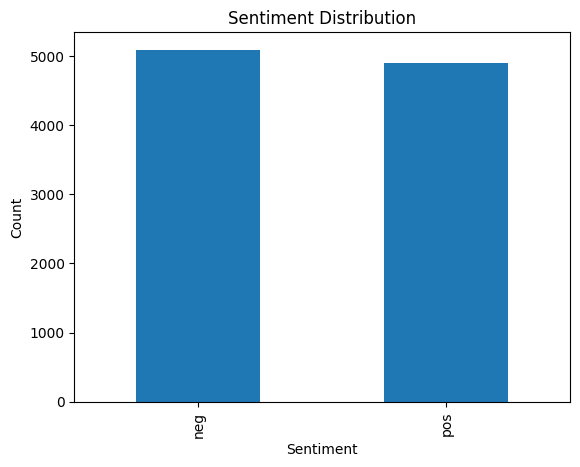

In [20]:
# sentiment distribution
import matplotlib.pyplot as plt

df['label'].value_counts().plot(kind='bar')
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

In [21]:
#word clouds

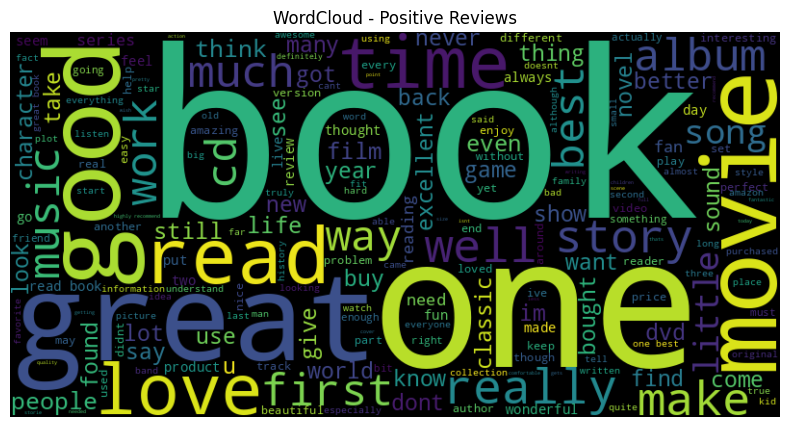

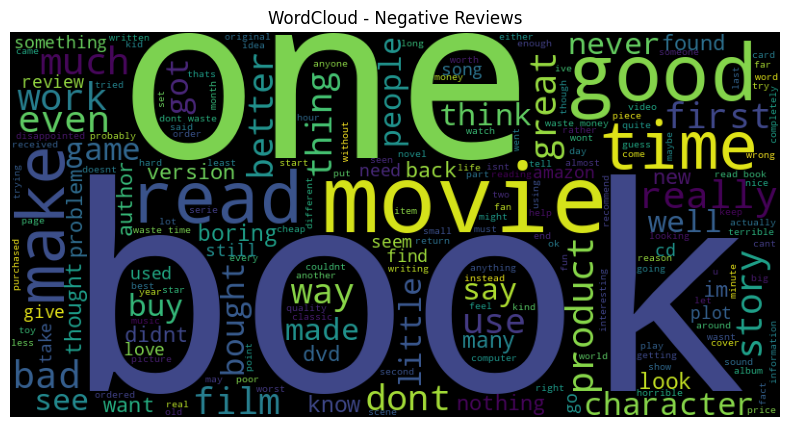

In [22]:
# Positive
positive_text = " ".join(df[df['label'] == 'pos']['clean_review'])

wordcloud_pos = WordCloud(width=800, height=400).generate(positive_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud_pos ,  interpolation='bilinear')
plt.axis("off")
plt.title("WordCloud - Positive Reviews")
plt.show()

# Negative
negative_text = " ".join(df[df['label'] == 'neg']['clean_review'])

wordcloud_neg = WordCloud(width=800, height=400).generate(negative_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud_neg)
plt.axis("off")
plt.title("WordCloud - Negative Reviews")
plt.show()

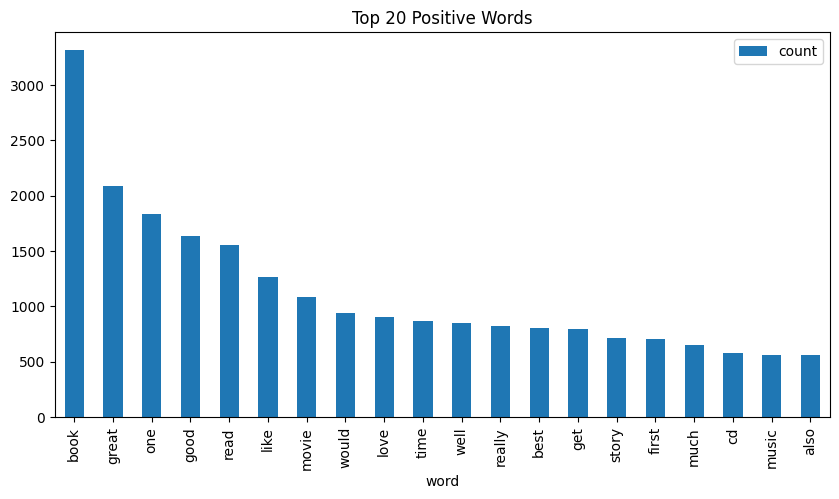

In [23]:
#most common positive/negative words
import seaborn as sns
pos_words = " ".join(df[df['label'] == 'pos']['clean_review']).split()
pos_common = Counter(pos_words).most_common(20)

pos_df = pd.DataFrame(pos_common, columns=['word','count'])
pos_df.plot(kind='bar', x='word', y='count', figsize=(10,5))
plt.title("Top 20 Positive Words")
plt.show()

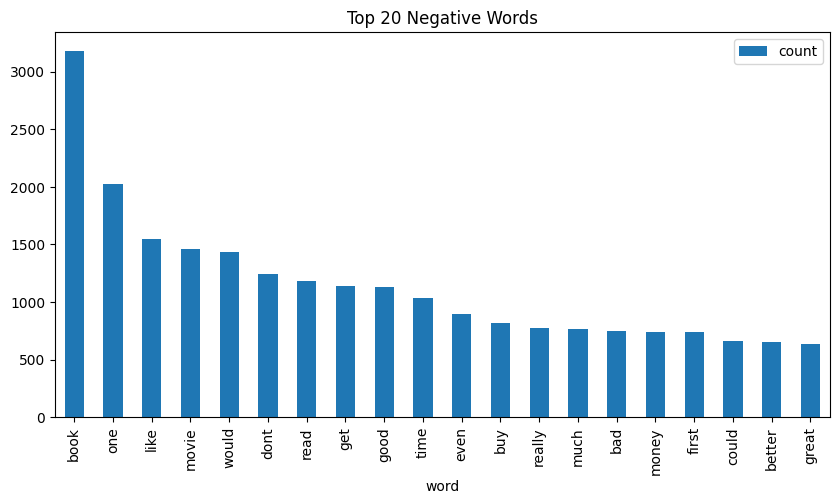

In [24]:
neg_words = " ".join(df[df['label']=='neg']['clean_review']).split()
neg_common = Counter(neg_words).most_common(20)

neg_df = pd.DataFrame(neg_common, columns=['word', 'count'])

neg_df.plot(kind='bar', x='word', y='count', figsize=(10,5))
plt.title("Top 20 Negative Words")
plt.show()

In [25]:
# split the dataset

from sklearn.model_selection import train_test_split
X = df['clean_review']
y = df['label']
X_train,X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [27]:
# Build the model of logistic regression
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train_tfidf,y_train)

y_pred_lr = lr.predict(X_test_tfidf)

In [28]:
# Build the model of svm
from sklearn.svm import LinearSVC

svm_model = LinearSVC()
svm_model.fit(X_train_tfidf,y_train)

y_pred_svm = svm_model.predict(X_test_tfidf)

In [29]:
# Build the model for Neural network
from sklearn.neural_network import MLPClassifier

nn = MLPClassifier(hidden_layer_sizes = (128,64), max_iter=10)
nn.fit(X_train_tfidf, y_train)

y_pred_nn = nn.predict(X_test_tfidf)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(


In [30]:
#validation:

In [31]:
# cross-validation for lr model
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(lr, X_train_tfidf, y_train, cv=5)
print("5-Fold CV F1 Scores:", cv_scores)
print("Mean F1-Score:", np.mean(cv_scores))

5-Fold CV F1 Scores: [0.845    0.8475   0.85375  0.835625 0.854375]
Mean F1-Score: 0.8472499999999998


In [32]:
# cross-validation for svm model

cv_scores = cross_val_score(svm_model, X_train_tfidf, y_train, cv=5)
print("5-Fold CV F1 Scores:", cv_scores)
print("Mean F1-Score:", np.mean(cv_scores))

5-Fold CV F1 Scores: [0.825625 0.828125 0.836875 0.826875 0.8375  ]
Mean F1-Score: 0.8310000000000001


In [33]:
# cross-validation for MLPClassifier model

cv_scores = cross_val_score(nn, X_train_tfidf, y_train, cv=5)
print("5-Fold CV F1 Scores:", cv_scores)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(


5-Fold CV F1 Scores: [0.811875 0.82375  0.808125 0.81625  0.818125]


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(


In [34]:
from sklearn.metrics import accuracy_score,classification_report, confusion_matrix

acc = accuracy_score(y_test, y_pred_lr)
print("Accuracy of Logistic Regression model:", acc)

acc = accuracy_score(y_test, y_pred_svm)
print("Accuracy of svm model:", acc)

acc = accuracy_score(y_test, y_pred_nn)
print("Accuracy of Neural network:", acc)

Accuracy of Logistic Regression model: 0.8385
Accuracy of svm model: 0.8395
Accuracy of Neural network: 0.824


In [35]:
print("classification_report of lr_model :\n",classification_report(y_test, y_pred_lr))

classification_report of lr_model :
               precision    recall  f1-score   support

         neg       0.85      0.84      0.84      1037
         pos       0.83      0.83      0.83       963

    accuracy                           0.84      2000
   macro avg       0.84      0.84      0.84      2000
weighted avg       0.84      0.84      0.84      2000



In [36]:
print("classification_report of svm_model :\n",classification_report(y_test, y_pred_svm))

classification_report of svm_model :
               precision    recall  f1-score   support

         neg       0.84      0.85      0.85      1037
         pos       0.83      0.83      0.83       963

    accuracy                           0.84      2000
   macro avg       0.84      0.84      0.84      2000
weighted avg       0.84      0.84      0.84      2000



In [37]:
print("classification_report of lr_model :\n",classification_report(y_test, y_pred_nn))

classification_report of lr_model :
               precision    recall  f1-score   support

         neg       0.83      0.83      0.83      1037
         pos       0.82      0.82      0.82       963

    accuracy                           0.82      2000
   macro avg       0.82      0.82      0.82      2000
weighted avg       0.82      0.82      0.82      2000

